<a href="https://colab.research.google.com/github/QuangDuy1512/ecommerce-behavior-analysis/blob/main/notebooks/02_sampling_strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cấu hình
import pandas as pd
import numpy as np
from pathlib import Path

INPUT_FILE = "/content/drive/MyDrive/personal_projects/2019-Dec.csv"
OUTPUT_FILE = "/content/drive/MyDrive/personal_projects/analysis_dataset.csv"
CHUNK_SIZE = 500000
SAMPLE_RATE = 0.01
RANDOM_STATE = 42

sampled_chunks = []
total_rows = 0
sampled_rows = 0

## Pipeline Lấy mẫu chính

In [ ]:
for chunk_id, chunk in enumerate(
    pd.read_csv(INPUT_FILE,chunksize=CHUNK_SIZE)
):
    print(f"\nProcessing Chunk {chunk_id+1}")
    total_rows += len(chunk)

    # Convert datetime - Chuyển đổi ngày giờ
    chunk["event_time"] = pd.to_datetime(chunk["event_time"],errors="coerce")

    # Extract Date - Trích xuất ngày - giờ
    chunk["HourKey"] = (chunk["event_time"].dt.strftime("%Y-%m-%d %H"))

    # Stratified Sampling by Date - Lấy mẫu phân tầng theo ngày
    daily_samples = []
    for date, group in chunk.groupby("HourKey"):
        sample_size = max(1,int(len(group)* SAMPLE_RATE))

        sampled_group = group.sample(n=sample_size,random_state=RANDOM_STATE)

        daily_samples.append(sampled_group)

    sampled_chunk = pd.concat(daily_samples,ignore_index=True)

    sampled_rows += len(sampled_chunk)

    sampled_chunks.append(sampled_chunk)

    print(f"Chunk Rows: {len(chunk):,}")
    print(f"Sampled Rows: {len(sampled_chunk):,}")


Processing Chunk 1
Chunk Rows: 500,000
Sampled Rows: 4,996

Processing Chunk 2
Chunk Rows: 500,000
Sampled Rows: 4,996

Processing Chunk 3
Chunk Rows: 500,000
Sampled Rows: 4,997

Processing Chunk 4
Chunk Rows: 500,000
Sampled Rows: 4,995

Processing Chunk 5
Chunk Rows: 500,000
Sampled Rows: 4,996

Processing Chunk 6
Chunk Rows: 500,000
Sampled Rows: 4,997

Processing Chunk 7
Chunk Rows: 500,000
Sampled Rows: 4,998

Processing Chunk 8
Chunk Rows: 500,000
Sampled Rows: 4,995

Processing Chunk 9
Chunk Rows: 500,000
Sampled Rows: 4,997

Processing Chunk 10
Chunk Rows: 500,000
Sampled Rows: 4,998

Processing Chunk 11
Chunk Rows: 500,000
Sampled Rows: 4,995

Processing Chunk 12
Chunk Rows: 500,000
Sampled Rows: 4,996

Processing Chunk 13
Chunk Rows: 500,000
Sampled Rows: 4,998

Processing Chunk 14
Chunk Rows: 500,000
Sampled Rows: 4,994

Processing Chunk 15
Chunk Rows: 500,000
Sampled Rows: 4,996

Processing Chunk 16
Chunk Rows: 500,000
Sampled Rows: 4,997

Processing Chunk 17
Chunk Rows: 

## Merge

In [ ]:
analysis_df = pd.concat(sampled_chunks,ignore_index=True)
analysis_df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,HourKey
0,2019-12-01 00:52:54+00:00,view,1004949,2053013563835941749,appliances.kitchen.refrigerators,oneplus,874.93,558866469,29cdf6e8-9529-4f8e-a0ea-8d4c5a6dc1e7,2019-12-01 00
1,2019-12-01 00:23:08+00:00,view,1004741,2232732093077520756,construction.tools.light,xiaomi,167.29,519274834,ac65e468-baea-46fe-b598-2fb0deaf26b2,2019-12-01 00
2,2019-12-01 00:19:43+00:00,view,100015449,2053013564154708873,apparel.jumper,versace,257.15,579425245,71c07288-18ec-42d3-a94b-dee781967f7c,2019-12-01 00
3,2019-12-01 00:44:52+00:00,view,26204341,2232732081585127530,construction.components.faucet,NaN,178.90,553836634,f0bdc895-23d2-4d79-b1b6-b0b24ebbde4e,2019-12-01 00
4,2019-12-01 00:33:13+00:00,view,5300032,2232732089269092627,NaN,rowenta,78.23,535120116,1d982a99-4f45-4096-aa84-4e1ce342e97f,2019-12-01 00
...,...,...,...,...,...,...,...,...,...,...
674982,2019-12-31 23:05:37+00:00,view,28101138,2232732113948377930,sport.bicycle,NaN,227.55,522022208,c70a3baa-cd2a-46c5-a9f2-e991bf7dba32,2019-12-31 23
674983,2019-12-31 23:59:27+00:00,view,17601078,2232732085393555647,furniture.living_room.sofa,skindoctors,50.45,516402760,728b8052-0a2e-4293-b782-5b8618515e74,2019-12-31 23
674984,2019-12-31 23:29:27+00:00,view,4803976,2232732079706079299,sport.bicycle,samsung,102.68,578179956,9a4fd057-f0da-42b3-83d4-cdac4905b9bf,2019-12-31 23
674985,2019-12-31 23:39:02+00:00,view,1005144,2232732093077520756,construction.tools.light,apple,1646.56,570599406,fe50c93f-c315-473b-828f-ab498e2cff8d,2019-12-31 23


## Shuffle Dataset

In [ ]:
analysis_df = analysis_df.sample(frac=1,random_state=RANDOM_STATE).reset_index(drop=True)

## Check Distribution - Kiểm tra phân phối

In [ ]:
date_distribution = (
    analysis_df
    .groupby("HourKey")
    .size()
)

print(date_distribution.head())
print(date_distribution.tail())

HourKey
2019-12-01 00    104
2019-12-01 01    171
2019-12-01 02    313
2019-12-01 03    576
2019-12-01 04    761
dtype: int64
HourKey
2019-12-31 19    466
2019-12-31 20    419
2019-12-31 21    275
2019-12-31 22    193
2019-12-31 23    122
dtype: int64


## Kiểm tra Time

In [ ]:
hour_distribution = (
    analysis_df
    .groupby("HourKey")
    .size()
)

print(
    "Total Hours:",
    len(hour_distribution)
)

Total Hours: 744


In [ ]:
all_hours = pd.date_range(
    start="2019-12-01 00:00:00",
    end="2019-12-31 23:00:00",
    freq="H"
)

missing_hours = set(
    all_hours.strftime("%Y-%m-%d %H")
) - set(
    analysis_df["HourKey"]
)

print(
    "Missing Hours:",
    len(missing_hours)
)

Missing Hours: 0


/tmp/ipykernel_1278/996018217.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_hours = pd.date_range(


## Plot Time Coverage

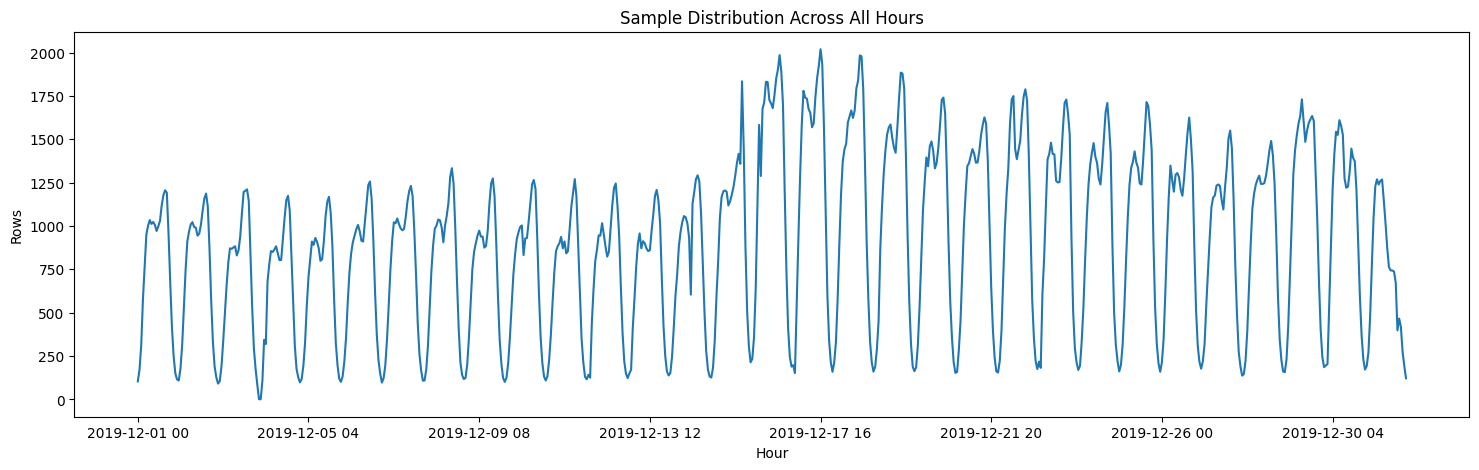

In [ ]:
import matplotlib.pyplot as plt
hour_distribution = (
    analysis_df
    .groupby("HourKey")
    .size()
)
plt.figure(figsize=(18,5))
hour_distribution.plot()
plt.title( "Sample Distribution Across All Hours")
plt.xlabel("Hour")
plt.ylabel("Rows")
plt.show()

## Kiểm tra bộ dữ liệu

In [ ]:
print("="*50)

print(f"Original Rows: {total_rows:,}")

print(f"Sampled Rows: {len(analysis_df):,}")

print(f"Products: "
    f"{analysis_df['product_id'].nunique():,}")

print(
    f"Users: "
    f"{analysis_df['user_id'].nunique():,}")

print(
    f"Brands: "
    f"{analysis_df['brand'].nunique():,}")

print(
    f"Date Range: "
    f"{analysis_df['HourKey'].min()} "
    f"→ "
    f"{analysis_df['HourKey'].max()}")

print("="*50)

Original Rows: 67,542,878
Sampled Rows: 674,987
Products: 80,369
Users: 489,628
Brands: 3,527
Date Range: 2019-12-01 00 → 2019-12-31 23


In [ ]:
analysis_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print(f"\nSaved to:\n{OUTPUT_FILE}")


Saved to:
/content/drive/MyDrive/personal_projects/analysis_dataset.csv
